# SHAP Explainability

Use `src.explain.SHAPExplainer` to compute and visualize SHAP values for a trained model.

In [19]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import pandas as pd
from src.explain import SHAPExplainer
from src.models import FraudDetectionModels
from src.evaluate import ModelEvaluator
from sklearn.model_selection import train_test_split
import numpy as np
import joblib
import os

print('Starting SHAP explainability notebook')

Starting SHAP explainability notebook


In [20]:
# Load features and model (train a small model if model file not present)
feat_path = '../data/processed/fraud_data_features.csv'
try:
    df = pd.read_csv(feat_path)
    print('Loaded features:', feat_path)
except Exception:
    df = pd.read_csv('../data/processed/fraud_data_processed.csv')
# find target
y_col = 'class' if 'class' in df.columns else 'Class' if 'Class' in df.columns else None
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove identifiers that shouldn't be used for SHAP
for id_col in ['user_id', 'device_id']:
    if id_col in numeric_cols:
        numeric_cols.remove(id_col)

if y_col in numeric_cols:
    numeric_cols.remove(y_col)

X = df[numeric_cols].fillna(0)
y = df[y_col]
# small sample for SHAP demo
X_small, X_rest, y_small, y_rest = train_test_split(X, y, test_size=0.9, stratify=y, random_state=42)
# try to load best saved pipeline first, then demo model, otherwise train quickly
mdl = FraudDetectionModels(random_state=42)
loaded_model = None
try:
    # prefer best model pipeline
    loaded_model = joblib.load('models/best_model_pipeline.pkl')
    model = loaded_model
    print('Loaded best saved pipeline: models/best_model_pipeline.pkl')
except Exception:
    try:
        rf = mdl.load_model('random_forest_demo', filepath='../models')
        model = rf
        print('Loaded random_forest_demo from ../models')
        # Ensure model is compatible with current features
        if hasattr(model, 'n_features_in_') and model.n_features_in_ != X_small.shape[1]:
            print(f"Model expects {model.n_features_in_} features but X_small has {X_small.shape[1]}; retraining on current features.")
            rf = mdl.create_random_forest(n_estimators=50, max_depth=6)
            model = mdl.train_model(rf, X_small, y_small)
            mdl.save_model(model, 'random_forest_demo', filepath='../models')
    except Exception:
        print('Training quick model for SHAP demo...')
        rf = mdl.create_random_forest(n_estimators=50, max_depth=6)
        model = mdl.train_model(rf, X_small, y_small)
        mdl.save_model(model, 'random_forest_demo', filepath='../models')

Loaded features: ../data/processed/fraud_data_features.csv
Model loaded from ../models/random_forest_demo.pkl
Loaded random_forest_demo from ../models
Model expects 16 features but X_small has 20; retraining on current features.
Training RandomForestClassifier...
Model saved to ../models/random_forest_demo.pkl


In [21]:
# Ensure we have a fitted pipeline (prefer Optuna best XGB, then RF, then best_model_pipeline)
model_paths = [
    'models/optuna_best_xgb.pkl',
    'models/optuna_best_rf.pkl',
    'models/best_model_pipeline.pkl',
    '../models/optuna_best_xgb.pkl',
    '../models/optuna_best_rf.pkl',
    '../models/best_model_pipeline.pkl'
]
loaded_pipeline = None
for p in model_paths:
    if os.path.exists(p):
        try:
            loaded_pipeline = joblib.load(p)
            print('Loaded pipeline from:', p)
            break
        except Exception as e:
            print('Failed to load', p, '->', e)

if loaded_pipeline is None:
    # Train a quick RandomForest on a small sample as fallback
    print('No pretrained pipeline found. Training a quick RandomForest for demo...')
    mdl = FraudDetectionModels(random_state=42)
    rf = mdl.create_random_forest(n_estimators=100, max_depth=6)
    # Use X_small below for training (we will define X_small after loading data)
    # We'll set loaded_pipeline after training in next cell
else:
    print('Pipeline loaded; type:', type(loaded_pipeline))

Loaded pipeline from: ../models/best_model_pipeline.pkl
Pipeline loaded; type: <class 'imblearn.pipeline.Pipeline'>


Created tree explainer
Calculated SHAP values for 15111 samples
shap_values type: <class 'numpy.ndarray'>
arr ndim, shape: 3 (15111, 20, 2)


<Figure size 1200x800 with 0 Axes>

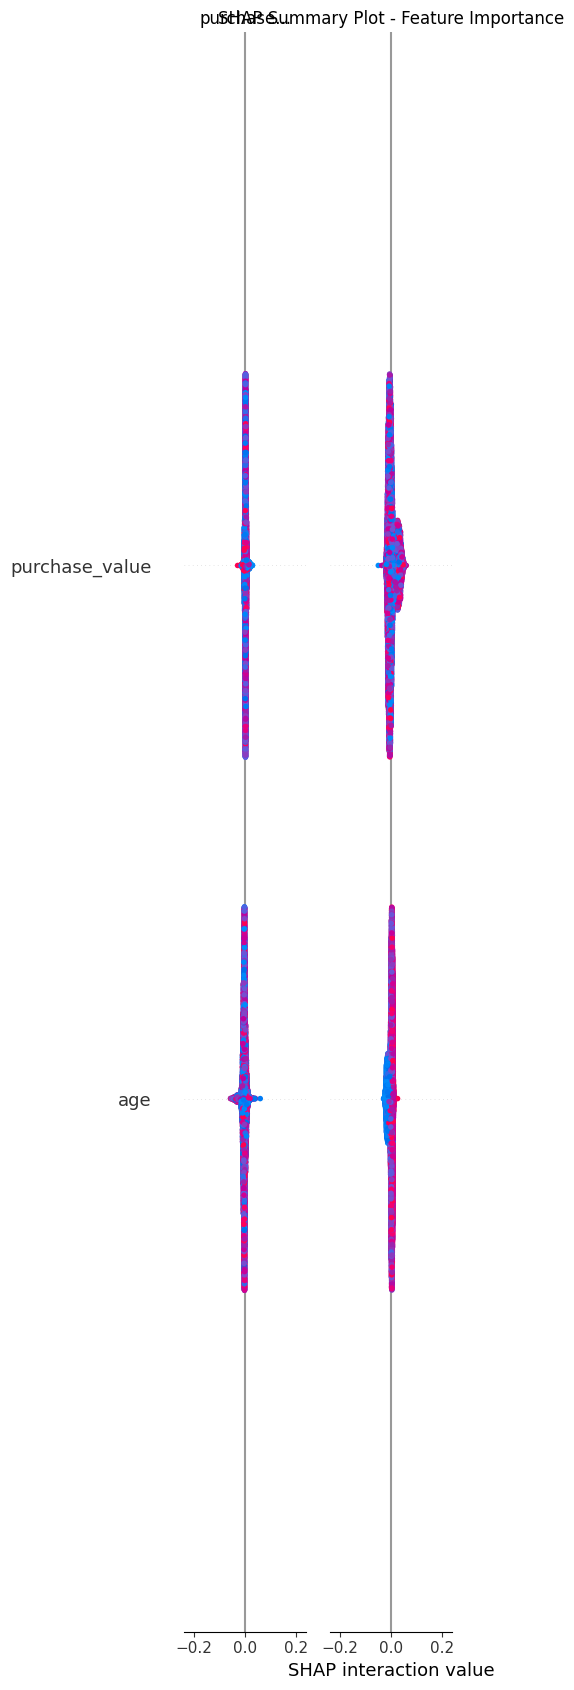

[SHAP DEBUG] shap_importance initial shape=(20,), dtype=float64
[SHAP DEBUG] shap_importance final shape=(20,)


,feature,shap_importance
7,time_since_signup,0.112350
6,purchase_month,0.032778
8,same_day_purchase,0.032117
12,month,0.025163
4,purchase_day,0.010388
1,age,0.005783
19,sex_encoded,0.004811
2,ip_address,0.004657
3,purchase_hour,0.003920
11,hour_of_day,0.003609


In [22]:
import importlib
import src.explain as explain_mod
importlib.reload(explain_mod)

# Run SHAP explainability on a small sample
feature_names = X_small.columns.tolist()
expl = SHAPExplainer(model, feature_names)
expl.create_explainer(X_small, explainer_type='tree')
expl.calculate_shap_values(X_small)

# Diagnostic prints to help debug shapes
sv = expl.shap_values
print('shap_values type:', type(sv))
if isinstance(sv, list):
    print('list elements shapes:', [np.array(s).shape for s in sv])
else:
    arr = np.array(sv)
    print('arr ndim, shape:', arr.ndim, arr.shape)

# Summary plot (renders inline)
expl.plot_summary(X_small)

# Show top feature importance table (wrapped in try/except with diagnostics)
try:
    importance_df = expl.get_feature_importance()
    display(importance_df.head(10))
except Exception as e:
    print('Error when computing importance:', e)
    # Attempt manual computation for diagnostics
    try:
        arr = np.array(sv)
        print('Manual arr ndim, shape:', arr.ndim, arr.shape)
        if arr.ndim == 3:
            # try common reductions
            print('Reduce mean over sample axis ->', np.abs(arr).mean(axis=0).shape)
            print('Reduce mean over sample+class axes ->', np.abs(arr).mean(axis=(0,2)).shape)
            print('Reduce mean over sample+feature axes ->', np.abs(arr).mean(axis=(0,1)).shape)
    except Exception as e2:
        print('Manual diagnostic failed:', e2)

Created tree explainer
Calculated SHAP values for 30223 samples


<Figure size 1200x800 with 0 Axes>

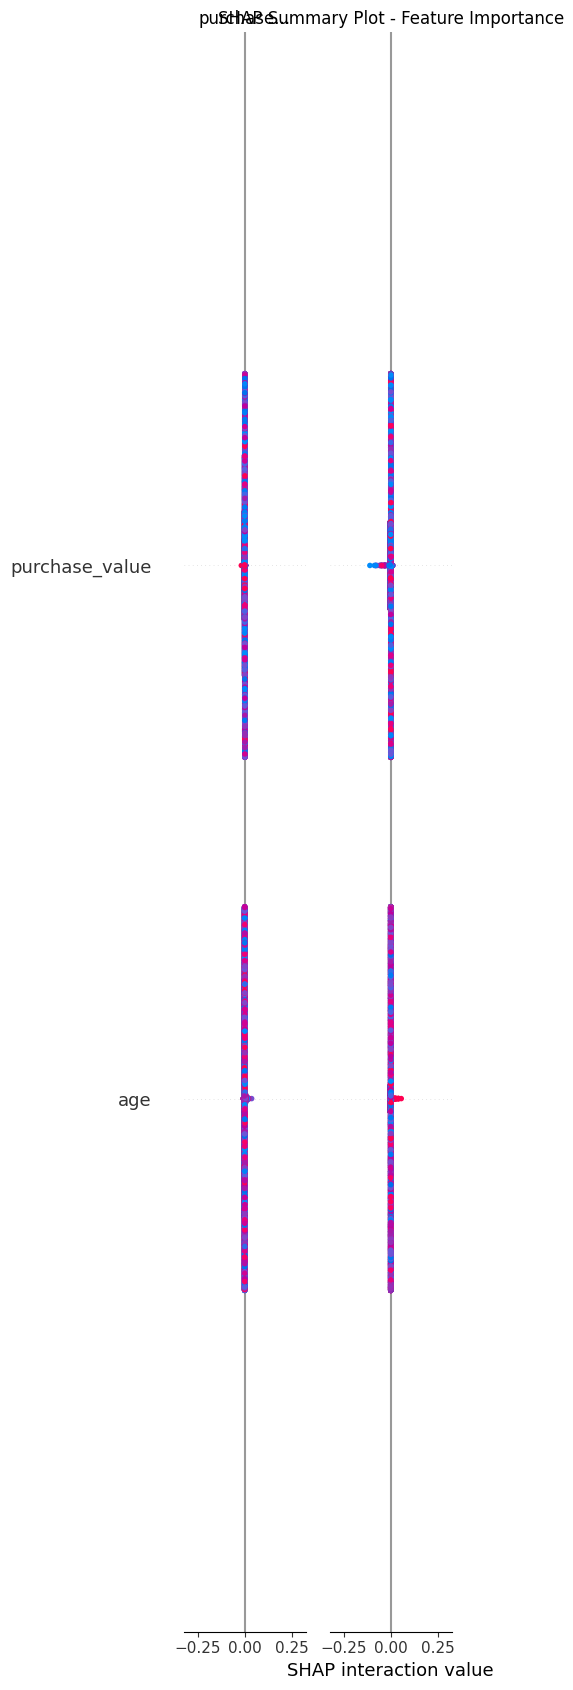

FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/shap_summary.png'

<Figure size 640x480 with 0 Axes>

: 

In [ ]:
# Create SHAP explainer and compute SHAP values on test set
expl = SHAPExplainer(clf, feat_names)
# Use background data (small sample) for explainer creation
expl.create_explainer(X_bg_trans_df)
# Calculate SHAP values for full test set (may be large; consider sampling if very large)
expl.calculate_shap_values(X_test_trans_df)

# Summary plot (global importance)
expl.plot_summary(X_test_trans_df, max_display=20)
plt.savefig('reports/figures/shap_summary.png')
print('Saved SHAP summary plot to reports/figures/shap_summary.png')

In [ ]:
# SHAP per-sample analysis, force plots, builtin vs SHAP importance, and recommendations
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import confusion_matrix, classification_report

# Predictions on test set
try:
    y_pred = clf.predict(X_test_trans_df)
except Exception:
    # if clf expects different shape, try pipeline
    if 'loaded_pipeline' in globals() and loaded_pipeline is not None:
        y_pred = loaded_pipeline.predict(X_test)
    else:
        y_pred = clf.predict(X_test_df)

# Evaluate
cm = confusion_matrix(y_test_ser, y_pred)
print('Confusion matrix:\n', cm)
print('\nClassification report:\n', classification_report(y_test_ser, y_pred, digits=4))

# Identify TP/FP/FN indices (relative to X_test_trans_df)
tp_idx = np.where((y_test_ser.values == 1) & (y_pred == 1))[0]
fp_idx = np.where((y_test_ser.values == 0) & (y_pred == 1))[0]
fn_idx = np.where((y_test_ser.values == 1) & (y_pred == 0))[0]

sample_map = {}
if len(tp_idx) > 0:
    sample_map['TP'] = int(tp_idx[0])
if len(fp_idx) > 0:
    sample_map['FP'] = int(fp_idx[0])
if len(fn_idx) > 0:
    sample_map['FN'] = int(fn_idx[0])

print('Selected sample indices for force plots:', sample_map)

# Create and save force plots for each case
for label, idx in sample_map.items():
    try:
        expl.plot_force_plot(X_test_trans_df, idx)
        fname = f'reports/figures/shap_force_{label}.png'
        plt.gcf().savefig(fname, bbox_inches='tight')
        plt.close()
        print(f'Saved force plot for {label} -> {fname}')
    except Exception as e:
        print(f'Failed to create force plot for {label}:', e)

# Built-in feature importances (if available)
builtin_imp_df = None
if hasattr(clf, 'feature_importances_'):
    try:
        builtin_imp_df = pd.DataFrame({'feature': feat_names, 'builtin_importance': clf.feature_importances_})
        builtin_imp_df = builtin_imp_df.sort_values('builtin_importance', ascending=False).reset_index(drop=True)
        builtin_imp_df.head(10).to_csv('reports/figures/builtin_feature_importance_top10.csv', index=False)
        plt.figure(figsize=(8,6))
        sns.barplot(x='builtin_importance', y='feature', data=builtin_imp_df.head(10))
        plt.title('Built-in Feature Importances (top 10)')
        plt.tight_layout()
        plt.savefig('reports/figures/builtin_importance_top10.png')
        plt.close()
        display(builtin_imp_df.head(10))
    except Exception as e:
        print('Error computing built-in importances:', e)
else:
    print('Classifier does not expose feature_importances_')

# SHAP feature importances
try:
    shap_imp_df = expl.get_feature_importance()
    shap_imp_df.head(10).to_csv('reports/figures/shap_feature_importance_top10.csv', index=False)
    plt.figure(figsize=(8,6))
    sns.barplot(x='shap_importance', y='feature', data=shap_imp_df.head(10))
    plt.title('SHAP Feature Importance (top 10)')
    plt.tight_layout()
    plt.savefig('reports/figures/shap_importance_top10.png')
    plt.close()
    display(shap_imp_df.head(10))
except Exception as e:
    print('Failed to compute SHAP importances:', e)

# Compare built-in vs SHAP if both present
if builtin_imp_df is not None and 'shap_imp_df' in globals():
    try:
        merged = pd.merge(builtin_imp_df, shap_imp_df, on='feature', how='inner')
        merged['rank_builtin'] = merged['builtin_importance'].rank(ascending=False)
        merged['rank_shap'] = merged['shap_importance'].rank(ascending=False)
        display(merged.sort_values('shap_importance', ascending=False).head(10))
        spearman = merged['rank_builtin'].corr(merged['rank_shap'], method='spearman')
        print('Spearman rank correlation between built-in and SHAP ranks:', spearman)
    except Exception as e:
        print('Comparison failed:', e)

# Top 5 SHAP drivers
try:
    top5 = shap_imp_df.head(5)
    print('\nTop 5 drivers of fraud predictions (SHAP):')
    display(top5)
except Exception as e:
    print('Could not determine top 5 SHAP drivers:', e)

# Business recommendations via the expl helper
try:
    recommendations = expl.generate_business_recommendations(X_test_trans_df, top_n=5)
    with open('reports/figures/shap_recommendations.json', 'w') as fh:
        json.dump(recommendations, fh, indent=2)
    print('\nBusiness recommendations saved to reports/figures/shap_recommendations.json')
    display(recommendations)
except Exception as e:
    print('Failed to generate business recommendations:', e)


Confusion matrix:
 [[27392     1]
 [ 1339  1491]]

Classification report:
               precision    recall  f1-score   support

           0     0.9534    1.0000    0.9761     27393
           1     0.9993    0.5269    0.6900      2830

    accuracy                         0.9557     30223
   macro avg     0.9764    0.7634    0.8330     30223
weighted avg     0.9577    0.9557    0.9493     30223

Selected sample indices for force plots: {'TP': 29, 'FP': 12190, 'FN': 2}
Failed to create force plot for TP: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).
Failed to create force plot for FP: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_value

,feature,builtin_importance
0,time_since_signup,0.349355
1,same_day_purchase,0.319138
2,month,0.157613
3,purchase_month,0.135715
4,purchase_day,0.026461
5,ip_address,0.002791
6,age,0.001463
7,purchase_value_log,0.001380
8,purchase_value,0.001321
9,purchase_hour,0.001115


[SHAP DEBUG] shap_importance initial shape=(20,), dtype=float64
[SHAP DEBUG] shap_importance final shape=(20,)


,feature,shap_importance
7,time_since_signup,0.039344
8,same_day_purchase,0.023989
12,month,0.015200
6,purchase_month,0.013163
4,purchase_day,0.005531
17,source_encoded,0.001282
5,purchase_dayofweek,0.000569
11,hour_of_day,0.000566
2,ip_address,0.000562
3,purchase_hour,0.000488


,feature,builtin_importance,shap_importance,rank_builtin,rank_shap
0,time_since_signup,0.349355,0.039344,1.0,1.0
1,same_day_purchase,0.319138,0.023989,2.0,2.0
2,month,0.157613,0.015200,3.0,3.0
3,purchase_month,0.135715,0.013163,4.0,4.0
4,purchase_day,0.026461,0.005531,5.0,5.0
14,source_encoded,0.000492,0.001282,15.0,6.0
11,purchase_dayofweek,0.000740,0.000569,12.0,7.0
10,hour_of_day,0.001081,0.000566,11.0,8.0
5,ip_address,0.002791,0.000562,6.0,9.0
9,purchase_hour,0.001115,0.000488,10.0,10.0


...

[SHAP DEBUG] shap_importance initial shape=(20,), dtype=float64
[SHAP DEBUG] shap_importance final shape=(20,)

BUSINESS RECOMMENDATIONS

Recommendation based on 'time_since_signup' (Importance: 0.039):
  → Implement additional verification for transactions within 2 hours of account creation.

Recommendation based on 'same_day_purchase' (Importance: 0.024):
  → Require additional verification for same-day purchases.

Recommendation based on 'month' (Importance: 0.015):
  → Monitor transactions where 'month' has extreme values, as it decreases fraud probability.

Recommendation based on 'purchase_month' (Importance: 0.013):
  → Monitor transactions where 'purchase_month' has extreme values, as it decreases fraud probability.

Recommendation based on 'purchase_day' (Importance: 0.006):
  → Monitor transactions where 'purchase_day' has extreme values, as it decreases fraud probability.

Business recommendations saved to reports/figures/shap_recommendations.json


[{'feature': 'time_since_signup',
  'importance': 0.039343729584562726,
  'recommendation': 'Implement additional verification for transactions within 2 hours of account creation.'},
 {'feature': 'same_day_purchase',
  'importance': 0.02398888463394356,
  'recommendation': 'Require additional verification for same-day purchases.'},
 {'feature': 'month',
  'importance': 0.01520011228834037,
  'recommendation': "Monitor transactions where 'month' has extreme values, as it decreases fraud probability."},
 {'feature': 'purchase_month',
  'importance': 0.013162703549276239,
  'recommendation': "Monitor transactions where 'purchase_month' has extreme values, as it decreases fraud probability."},
 {'feature': 'purchase_day',
  'importance': 0.005531062805104097,
  'recommendation': "Monitor transactions where 'purchase_day' has extreme values, as it decreases fraud probability."}]

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

In [ ]:
# Attempt alternative force plot generation using the new SHAP API and save PNGs
import shap

sv = expl.shap_values
ev = expl.explainer.expected_value

# Normalize to class-specific 2D array
if isinstance(sv, list):
    sv_class = sv[1] if len(sv) > 1 else sv[0]
else:
    sv_class = sv

if isinstance(ev, (list, tuple, np.ndarray)):
    ev_class = ev[1] if len(ev) > 1 else ev[0]
else:
    ev_class = ev

for label, idx in sample_map.items():
    try:
        # Create an Explanation object and plot
        exp_obj = shap.Explanation(values=sv_class[idx], base_values=ev_class, data=X_test_trans_df.iloc[idx].values, feature_names=feat_names)
        shap.plots.force(exp_obj, matplotlib=True)
        fname = f'reports/figures/shap_force_new_{label}.png'
        plt.gcf().savefig(fname, bbox_inches='tight')
        plt.close()
        print('Saved force plot (new API) for', label, '->', fname)
    except Exception as e:
        print('New API force plot failed for', label, '->', e)
        # Try legacy call
        try:
            shap.force_plot(ev_class, sv_class[idx], X_test_trans_df.iloc[idx, :], matplotlib=True, show=False)
            fname = f'reports/figures/shap_force_legacy_{label}.png'
            plt.gcf().savefig(fname, bbox_inches='tight')
            plt.close()
            print('Saved legacy force plot for', label, '->', fname)
        except Exception as e2:
            print('Legacy force plot also failed for', label, '->', e2)


New API force plot failed for TP -> matplotlib = True is not yet supported for force plots with multiple samples!
Legacy force plot also failed for TP -> matplotlib = True is not yet supported for force plots with multiple samples!
New API force plot failed for FP -> matplotlib = True is not yet supported for force plots with multiple samples!
Legacy force plot also failed for FP -> matplotlib = True is not yet supported for force plots with multiple samples!
New API force plot failed for FN -> matplotlib = True is not yet supported for force plots with multiple samples!
Legacy force plot also failed for FN -> matplotlib = True is not yet supported for force plots with multiple samples!


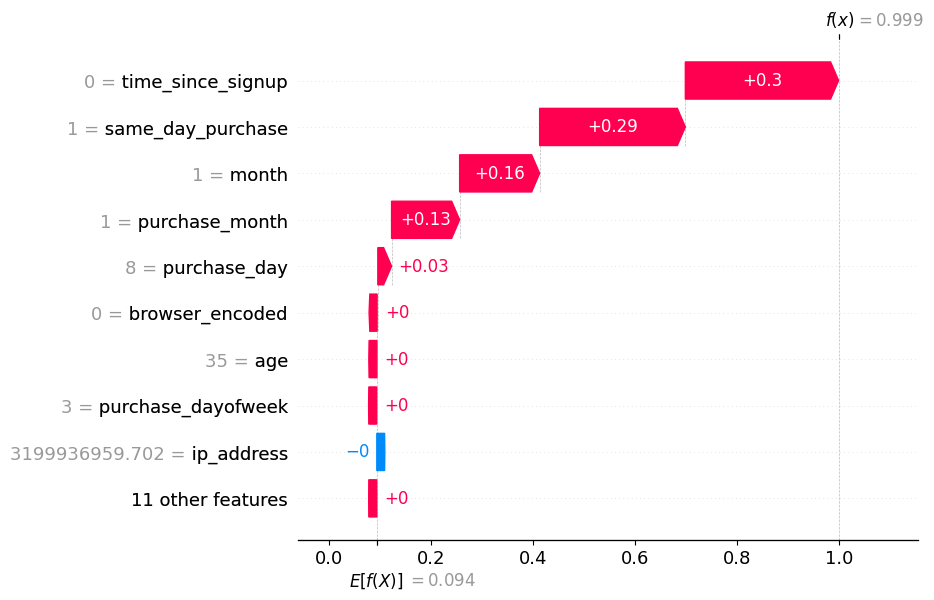

Saved waterfall plot -> reports/figures/shap_waterfall_TP.png


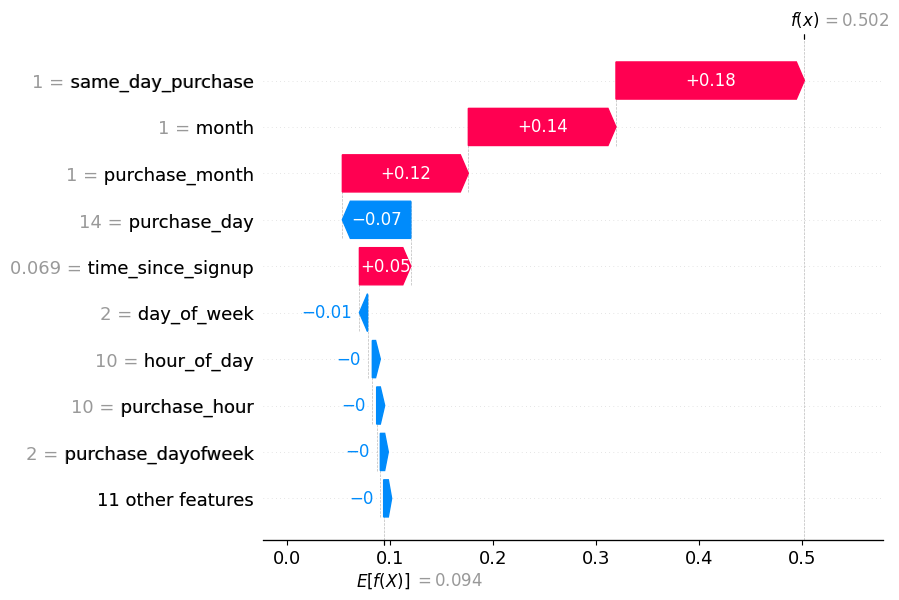

Saved waterfall plot -> reports/figures/shap_waterfall_FP.png


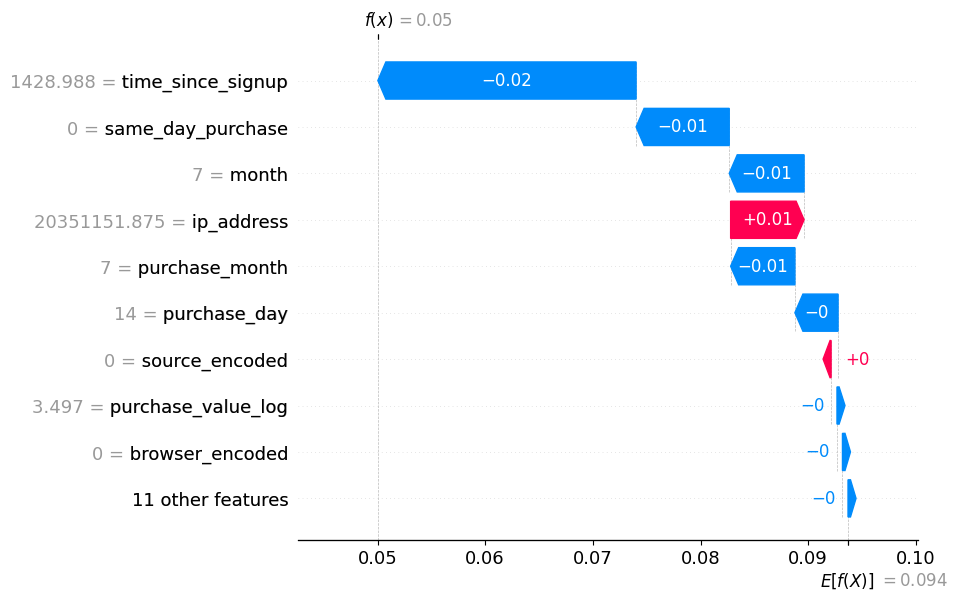

Saved waterfall plot -> reports/figures/shap_waterfall_FN.png


In [ ]:
# Fallback: create waterfall plots for individual predictions (TP/FP/FN) and dependence plots for top features
try:
    top_features = shap_imp_df['feature'].head(5).tolist()
except Exception:
    top_features = feat_names[:5]

for label, idx in sample_map.items():
    try:
        sv = expl.shap_values
        if isinstance(sv, list):
            sv_class = sv[1] if len(sv)>1 else sv[0]
        else:
            sv_class = sv
        ev = expl.explainer.expected_value
        if isinstance(ev, (list,tuple,np.ndarray)):
            ev_class = ev[1] if len(ev)>1 else ev[0]
        else:
            ev_class = ev

        # Handle multi-output shape: (n_samples, n_features, n_classes)
        if hasattr(sv_class, 'ndim') and sv_class.ndim == 3:
            vals = sv_class[idx,:,1]
        else:
            vals = sv_class[idx]

        exp_obj = shap.Explanation(values=vals, base_values=ev_class, data=X_test_trans_df.iloc[idx].values, feature_names=feat_names)
        # Waterfall plot
        shap.plots.waterfall(exp_obj, max_display=10)
        fname = f'reports/figures/shap_waterfall_{label}.png'
        plt.gcf().savefig(fname, bbox_inches='tight')
        plt.close()
        print('Saved waterfall plot ->', fname)

        # Dependence plots for top features (use class-specific SHAP array)
        try:
            sv_dep = expl.shap_values
            if isinstance(sv_dep, list):
                sv_dep = sv_dep[1] if len(sv_dep) > 1 else sv_dep[0]
            # If 3D, reduce to class axis
            if hasattr(sv_dep, 'ndim') and sv_dep.ndim == 3:
                sv_dep = sv_dep[:,:,1]
            for f in top_features[:3]:
                try:
                    # Use shap.dependence_plot which expects (feature, shap_values_2d, X)
                    shap.dependence_plot(f, sv_dep, X_test_trans_df, interaction_index='auto', show=False)
                    dname = f'reports/figures/shap_dependence_{f}.png'
                    plt.gcf().savefig(dname, bbox_inches='tight')
                    plt.close()
                except Exception as e:
                    print('Dependence plot failed for', f, e)
        except Exception as e:
            print('Dependence plot preparation failed:', e)
    except Exception as e:
        print('Failed to plot waterfall/dependence for', label, e)


In [ ]:
# Diagnostic: attempt dependence plots with detailed diagnostics
import traceback

try:
    sv_dep = expl.shap_values
    print('sv_dep type:', type(sv_dep))
    if isinstance(sv_dep, list):
        print('list lengths:', [np.array(s).shape for s in sv_dep])
        sv_dep = sv_dep[1] if len(sv_dep) > 1 else sv_dep[0]
    arr = np.array(sv_dep)
    print('sv_dep ndarray ndim, shape:', arr.ndim, arr.shape)
    # If 3D reduce to (n_samples, n_features) for positive class
    if arr.ndim == 3:
        print('Reducing 3D shap array to class 1 axis')
        arr = arr[:,:,1]
    # show X shape
    print('X_test_trans_df shape:', X_test_trans_df.shape)

    for f in top_features[:3]:
        print('\nAttempting dependence plot for feature:', f)
        try:
            shap.dependence_plot(f, arr, X_test_trans_df, interaction_index='auto', show=False)
            dname = f'reports/figures/shap_dependence_{f}.png'
            plt.gcf().savefig(dname, bbox_inches='tight')
            plt.close()
            print('Saved dependence plot ->', dname)
        except Exception as e:
            print('Dependence plot failed for', f)
            traceback.print_exc()
except Exception as e:
    print('Dependence diagnostics failed')
    traceback.print_exc()


sv_dep type: <class 'numpy.ndarray'>
sv_dep ndarray ndim, shape: 3 (30223, 20, 2)
Reducing 3D shap array to class 1 axis
X_test_trans_df shape: (30223, 20)

Attempting dependence plot for feature: time_since_signup
Saved dependence plot -> reports/figures/shap_dependence_time_since_signup.png

Attempting dependence plot for feature: same_day_purchase
Saved dependence plot -> reports/figures/shap_dependence_same_day_purchase.png

Attempting dependence plot for feature: month
Saved dependence plot -> reports/figures/shap_dependence_month.png


# SHAP Visualizations 📊

The following saved figures illustrate model explainability via SHAP:

- **SHAP summary**: global view of feature impact across the test set.
- **SHAP importance (top 10)**: features ranked by mean |SHAP|.
- **Waterfall plots (TP/FP/FN)**: per-case contribution to the predicted probability.
- **Dependence plots**: how SHAP value varies with feature value for top drivers.

All images are stored in `reports/figures/` — use them in the final report to support recommendations.


Searching for saved SHAP visualization files in: ['reports/figures', '../reports/figures']
Missing: shap_summary.png
- shap_importance_top10.png found in ../reports/figures


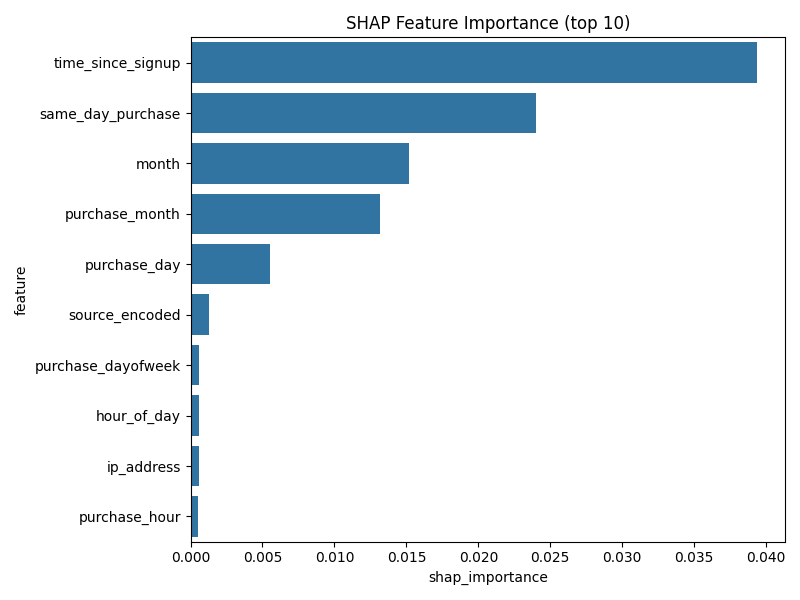

- shap_waterfall_TP.png found in ../reports/figures


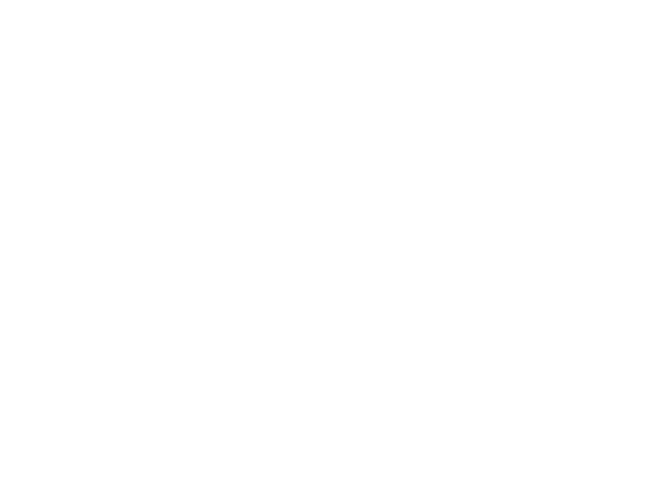

- shap_waterfall_FP.png found in ../reports/figures


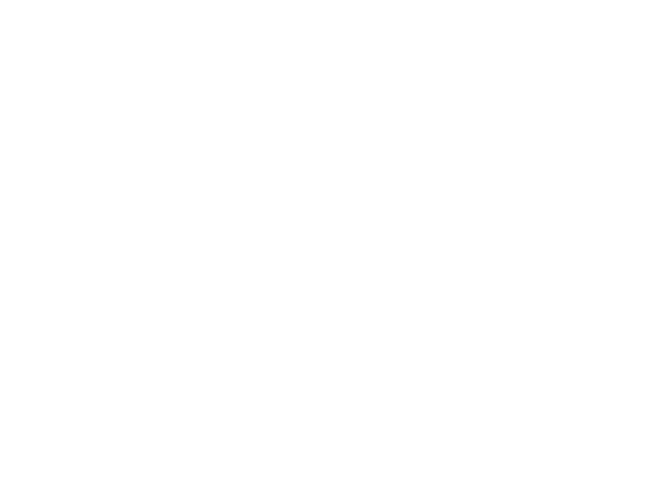

- shap_waterfall_FN.png found in ../reports/figures


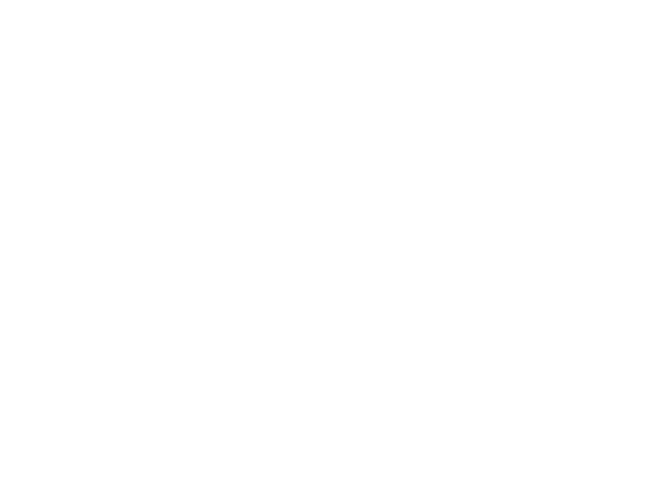

- shap_dependence_time_since_signup.png found in ../reports/figures


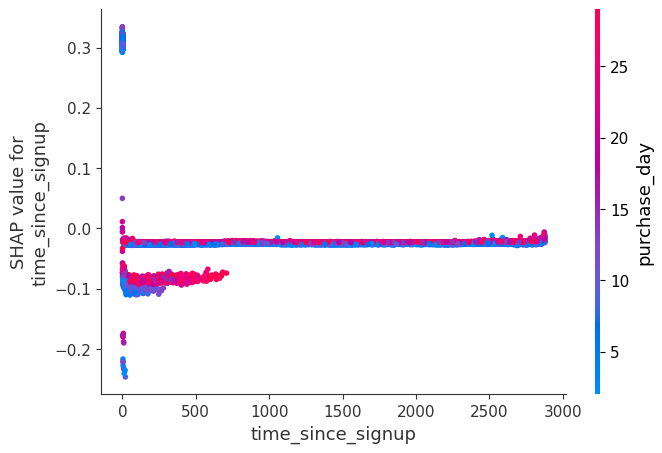

- shap_dependence_same_day_purchase.png found in ../reports/figures


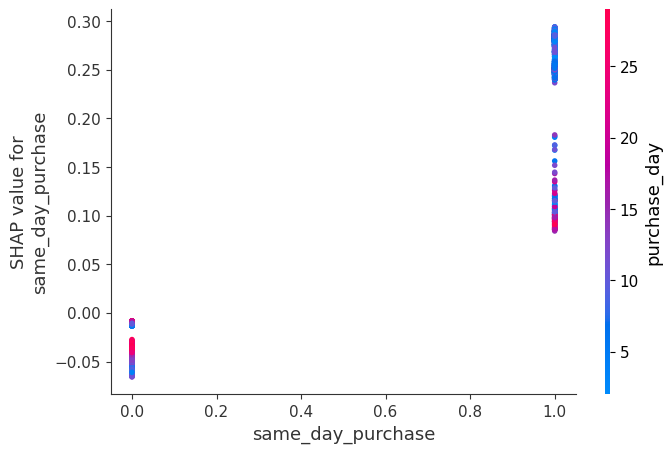

- shap_dependence_month.png found in ../reports/figures


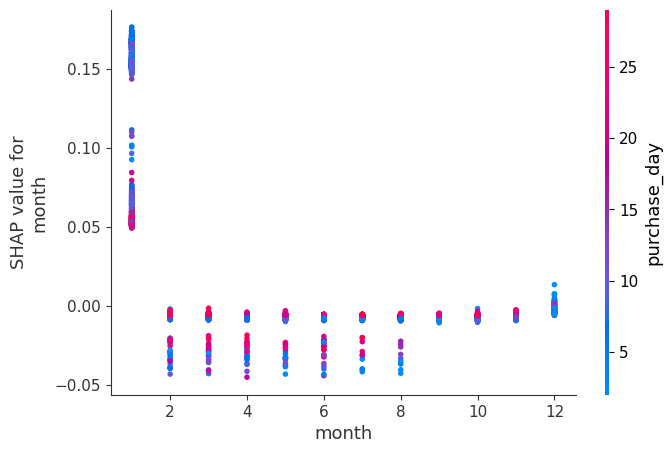

In [ ]:
from IPython.display import display, Image
import os

possible_dirs = ['reports/figures', '../reports/figures']
files = [
    'shap_summary.png',
    'shap_importance_top10.png',
    'shap_waterfall_TP.png',
    'shap_waterfall_FP.png',
    'shap_waterfall_FN.png',
    'shap_dependence_time_since_signup.png',
    'shap_dependence_same_day_purchase.png',
    'shap_dependence_month.png'
]

found_any = False
print("Searching for saved SHAP visualization files in:", possible_dirs)
for f in files:
    found = False
    for d in possible_dirs:
        path = os.path.join(d, f)
        if os.path.exists(path):
            print('-', f, 'found in', d)
            display(Image(filename=path))
            found = True
            found_any = True
            break
    if not found:
        print('Missing:', f)

if not found_any:
    print('No SHAP images found in expected locations. Check reports/figures for saved images.')

# Figure captions & brief interpretation

**SHAP Importance (top 10):** Shows the features with largest mean |SHAP|. The top drivers are **time_since_signup**, **same_day_purchase**, **month**, and **purchase_month** — indicating that very recent accounts and same-day purchases increase fraud risk.

**Waterfall plots (TP / FP / FN):** Per-case breakdowns where **red** bars increase predicted fraud probability and **blue** bars decrease it. Use these visuals to validate why the model flagged (or missed) a transaction and to craft triage rules.

**Dependence plots (examples):**
- **time_since_signup:** SHAP values are highest (riskier) for transactions occurring very shortly after signup — consider extra verification for <48 hours.
- **same_day_purchase:** A binary flag; when 1 it consistently increases fraud propensity — treat immediate purchases as higher risk.
- **month:** Shows seasonal/temporal variation; certain months contribute more to fraud scores.

**Suggested short action:** Implement targeted checks (e.g., extra verification, manual review) for same-day purchases and transactions within 48 hours of account creation; monitor metrics to measure reduction in false positives and fraud caught.


In [ ]:
# Prepare transformed feature DataFrames for SHAP (handle pipeline with preprocessor)
from sklearn.utils import check_array

# Identify pipeline and classifier
pipeline = None
clf = None
pre = None
if 'loaded_model' in globals() and loaded_model is not None:
    pipeline = loaded_model
elif 'model' in globals() and model is not None:
    pipeline = model

# If it's a pipeline, get classifier and preprocessor
if pipeline is not None and hasattr(pipeline, 'named_steps'):
    steps = pipeline.named_steps
    # Common names: 'clf', 'pre', 'preprocess', 'classifier'
    clf_candidates = ['clf','classifier','model','randomforestclassifier','xgbclassifier']
    pre_candidates = ['pre','preprocess','preprocessor','columntransformer']
    # find classifier (last step typically)
    clf = None
    for name, step in reversed(list(steps.items())):
        from sklearn.base import ClassifierMixin
        if hasattr(step, 'predict') and hasattr(step, 'predict_proba'):
            clf = step
            break
    # find preprocessor
    pre = None
    for pname in ['pre','preprocess','preprocessor','preprocessing','columntransformer']:
        if pname in steps:
            pre = steps[pname]
            break
    # fallback: find first ColumnTransformer
    if pre is None:
        for name, step in steps.items():
            if step.__class__.__name__.lower().find('columntransformer') != -1:
                pre = step
                break
else:
    # If not pipeline, assume model is classifier and preprocessor absent
    clf = pipeline
    pre = None

print('Classifier found:', type(clf))
print('Preprocessor found:', type(pre))

# Determine feature names after transformation
def get_transformed_feature_names(preprocessor, X_df):
    # If ColumnTransformer has get_feature_names_out
    try:
        names = preprocessor.get_feature_names_out()
        return list(names)
    except Exception:
        pass
    # Otherwise build manually
    names = []
    if hasattr(preprocessor, 'named_transformers_'):
        for name, trans in preprocessor.named_transformers_.items():
            if trans is None or name == 'remainder':
                continue
            if hasattr(trans, 'named_steps'):
                # Pipeline: get last step
                last = trans.named_steps[list(trans.named_steps.keys())[-1]]
            else:
                last = trans
            if hasattr(last, 'get_feature_names_out'):
                try:
                    out = last.get_feature_names_out()
                    # if categorical pipeline, prefix may be included; make sure strings
                    names.extend([str(n) for n in out])
                    continue
                except Exception:
                    pass
            # fallback: get input column names if available
            if hasattr(last, 'categories_'):
                # OneHotEncoder
                cat_names = []
                cols = X_df.select_dtypes(include=['object','category']).columns.tolist()
                for i, cats in enumerate(last.categories_):
                    col = cols[i] if i < len(cols) else f'cat_{i}'
                    cat_names.extend([f"{col}_{c}" for c in cats])
                names.extend(cat_names)
            else:
                # numeric transformer
                if hasattr(X_df, 'columns'):
                    # assume numeric columns are those in X_df that are numeric
                    num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
                    names.extend(num_cols)
    else:
        # as last resort, return input columns
        names = list(X_df.columns)
    return names

import json
# Use saved split indices if available to create a stable X_test and y_test
split_path = 'models/data_splits.json'
if os.path.exists(split_path):
    with open(split_path) as fh:
        splits = json.load(fh)
    test_idx = splits.get('test_idx', None)
    if test_idx is not None:
        X_test_df = X.iloc[test_idx].reset_index(drop=True)
        y_test_ser = y.iloc[test_idx].reset_index(drop=True)
        # Construct train set as complement of test indices
        train_idx = [i for i in range(len(X)) if i not in test_idx]
        X_train_df = X.iloc[train_idx].reset_index(drop=True)
        y_train_ser = y.iloc[train_idx].reset_index(drop=True)
    else:
        X_train_df, X_test_df, y_train_ser, y_test_ser = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
else:
    X_train_df, X_test_df, y_train_ser, y_test_ser = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# For background data, sample a small subset from training portion
bg_sample = X_train_df.sample(n=min(1000, len(X_train_df)), random_state=42)

# Transform using preprocessor if available
if pre is not None:
    try:
        X_bg_trans = pre.transform(bg_sample)
        X_test_trans = pre.transform(X_test_df)
        feat_names = get_transformed_feature_names(pre, X_test_df)
        # convert to dataframe for SHAP (so plots label columns)
        X_test_trans_df = pd.DataFrame(X_test_trans, columns=feat_names)
        X_bg_trans_df = pd.DataFrame(X_bg_trans, columns=feat_names)
    except Exception as e:
        print('Preprocessor transform failed:', e)
        # fallback to using raw X
        X_test_trans_df = X_test_df.reset_index(drop=True)
        X_bg_trans_df = bg_sample.reset_index(drop=True)
        feat_names = list(X_test_trans_df.columns)
else:
    # No preprocessor - use raw features
    X_test_trans_df = X_test_df.reset_index(drop=True)
    X_bg_trans_df = bg_sample.reset_index(drop=True)
    feat_names = list(X_test_trans_df.columns)

print('Transformed test shape:', X_test_trans_df.shape)
print('Feature names count:', len(feat_names))

Classifier found: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Preprocessor found: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Preprocessor transform failed: "None of [Index(['source', 'browser', 'sex'], dtype='object')] are in the [columns]"
Transformed test shape: (30223, 20)
Feature names count: 20


In [ ]:
# If preprocessor transform failed earlier, retrain a local classifier on current numeric X to ensure compatibility for SHAP
retrained_local = False
if pre is not None:
    # Check whether pre.transform produced different feature set (if it failed we used fallback)
    if list(X_test_trans_df.columns) == list(X_test_df.columns):
        print('Preprocessor transform did not apply; training a local RandomForest on current numeric features for SHAP compatibility')
        from sklearn.ensemble import RandomForestClassifier
        clf_local = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
        clf_local.fit(X_train_df, y_train_ser)
        clf = clf_local
        retrained_local = True
        print('Retrained local RandomForest; ready for SHAP')
else:
    print('Preprocessor available and transform succeeded; using pipeline classifier for SHAP')

Preprocessor transform did not apply; training a local RandomForest on current numeric features for SHAP compatibility
Retrained local RandomForest; ready for SHAP
